In [1]:
# GPU setup (TensorFlow)
import os

# Reduce GPU memory fragmentation and allow growth
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as e:
            print(f"Could not set memory growth: {e}")
    print("GPUs available:", gpus)
else:
    print("No GPU found. Using CPU.")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.layers import RepeatVector
from keras.layers import Dropout
from keras.layers import TimeDistributed
from keras.models import Model
from keras.layers import Input

In [3]:
# Load extracted dataset from local folder
import os, glob

data_dir = "ExtractedData"
preferred_files = ["dayr4.2.csv", "weekr4.2.csv", "sessionr4.2.csv"]
data_path = None
for name in preferred_files:
    candidate = os.path.join(data_dir, name)
    if os.path.exists(candidate):
        data_path = candidate
        break
if data_path is None:
    csv_files = sorted(glob.glob(os.path.join(data_dir, "*.csv")))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {data_dir}")
    data_path = csv_files[0]

data = pd.read_csv(data_path)
print(f"Loaded: {data_path}")
print("Columns:", list(data.columns))

Loaded: ExtractedData\dayr4.2.csv
Columns: ['starttime', 'endtime', 'user', 'day', 'week', 'isweekday', 'isweekend', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin', 'O', 'C', 'E', 'A', 'N', 'n_allact', 'allact_n-pc0', 'allact_n-pc1', 'allact_n-pc2', 'allact_n-pc3', 'n_workhourallact', 'workhourallact_n-pc0', 'workhourallact_n-pc1', 'workhourallact_n-pc2', 'workhourallact_n-pc3', 'n_afterhourallact', 'afterhourallact_n-pc0', 'afterhourallact_n-pc1', 'afterhourallact_n-pc2', 'afterhourallact_n-pc3', 'n_logon', 'logon_n-pc0', 'logon_n-pc1', 'logon_n-pc2', 'logon_n-pc3', 'n_workhourlogon', 'workhourlogon_n-pc0', 'workhourlogon_n-pc1', 'workhourlogon_n-pc2', 'workhourlogon_n-pc3', 'n_afterhourlogon', 'afterhourlogon_n-pc0', 'afterhourlogon_n-pc1', 'afterhourlogon_n-pc2', 'afterhourlogon_n-pc3', 'n_usb', 'usb_mean_usb_dur', 'usb_n-pc0', 'usb_n-pc1', 'usb_n-pc2', 'usb_n-pc3', 'n_workhourusb', 'workhourusb_mean_usb_dur', 'workhourusb_n-pc0', 'workhourusb_n-pc1', 'workhourusb_n-pc2', 'wo

In [4]:
label_encoder = LabelEncoder()

candidate_targets = ["label", "target", "class", "is_malicious", "malicious", "anomaly", "insider", "is_insider", "risk"]
target_column = next((c for c in candidate_targets if c in data.columns), data.columns[-1])
Y = label_encoder.fit_transform(data[target_column])
print(f"Target column: {target_column}")

Target column: insider


In [5]:
scaler = StandardScaler()

features = data.drop(columns=[target_column])
features = features.apply(pd.to_numeric, errors="coerce").fillna(0.0)
X = scaler.fit_transform(features.values)

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3)

In [7]:
X_train

array([[ 1.72420884,  1.72420884,  0.82810769, ...,  0.        ,
         0.        ,  0.        ],
       [-1.45275421, -1.45275421, -1.60502461, ...,  0.        ,
         0.        ,  0.        ],
       [-1.17468305, -1.17468305, -0.40232246, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.78571866,  0.78571866,  0.38792564, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.74400799,  0.74400799, -0.38499246, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.18786566,  0.18786566, -0.37459446, ...,  0.        ,
         0.        ,  0.        ]])

In [8]:
X_train.shape

(231316, 507)

In [9]:
numx = X_train
numx.shape
x_train = np.reshape(numx, (numx.shape[0],numx.shape[1],1))

In [10]:
x_train.shape

(231316, 507, 1)

In [11]:
Y_train.shape

(231316,)

In [12]:
numy = Y_train
numy.shape
# y_train = np.reshape(numy, (numx.shape[0],numx.shape[1],1))

(231316,)

In [13]:
y_train = np.reshape(numy, (numy.shape[0],1))

In [14]:
y_train.shape

(231316, 1)

In [15]:
inputs = Input(shape=(X_train.shape[1], 1))
encoded = LSTM(32)(inputs)
decoded = RepeatVector(X_train.shape[1])(encoded)
decoded = LSTM(32, return_sequences=True)(decoded)
decoded = Dense(1, activation='sigmoid')(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error',metrics=['accuracy'])

In [16]:
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 507, 1)]          0         
                                                                 
 lstm (LSTM)                 (None, 32)                4352      
                                                                 
 repeat_vector (RepeatVector  (None, 507, 32)          0         
 )                                                               
                                                                 
 lstm_1 (LSTM)               (None, 507, 32)           8320      
                                                                 
 dense (Dense)               (None, 507, 1)            33        
                                                                 
Total params: 12,705
Trainable params: 12,705
Non-trainable params: 0
_________________________________________________________

In [17]:
numtx = X_test
numtx.shape
x_test = np.reshape(numtx, (numtx.shape[0],numtx.shape[1],1))

In [18]:
X_test.shape

(99136, 507)

In [19]:
x_test.shape

(99136, 507, 1)

In [20]:
numty = Y_test
numty.shape

(99136,)

In [21]:
y_test = np.reshape(numty, (numty.shape[0],1))

In [22]:
y_test.shape

(99136, 1)

In [24]:
autoencoder_history = autoencoder.fit(
    x_train,
    y_train,
    epochs=1,
    batch_size=16,
    validation_data=(x_test, y_test)
)

14458/14458 [==============================] - 1094s 76ms/step - loss: 0.0111 - accuracy: 0.9972 - val_loss: 0.0108 - val_accuracy: 0.9974


In [25]:
def predict_in_batches(model, data, batch_size=8):
    preds = []
    for i in range(0, len(data), batch_size):
        batch = data[i : i + batch_size]
        preds.append(model.predict(batch, batch_size=batch_size, verbose=0))
    return np.concatenate(preds, axis=0)

y_pred_test = predict_in_batches(autoencoder, x_test, batch_size=8)

In [26]:
y_pred_train = predict_in_batches(autoencoder, x_train, batch_size=8)

KeyboardInterrupt: 

In [27]:
y_pred_test.shape

(99136, 507, 1)

In [ ]:
train_mae_loss = np.mean(np.abs(y_pred_train - x_train), axis=1)

# plt.hist(train_mae_loss, bins=50)
# plt.xlabel('Train MAE loss')
# plt.ylabel('Number of Samples');

threshold = np.max(train_mae_loss)
print(f'Reconstruction error threshold: {threshold}')

Reconstruction error threshold: 2.8033417025832836


In [28]:
test_mae_loss = np.mean(np.abs(y_pred_test - x_test), axis=1)
# np.max(test_mae_loss)
print(f'Validation Reconstruction error loss: {np.max(test_mae_loss)}')

Validation Reconstruction error loss: 7.774904050935915


In [29]:
autoencoder.save("model")

INFO:tensorflow:Assets written to: model\assets


INFO:tensorflow:Assets written to: model\assets


In [30]:
autoencoder.save("model.h5")

In [31]:
preds = np.argmax(autoencoder.predict(x_test), axis=1)

3098/3098 [==============================] - 111s 36ms/step


In [32]:
preds

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], dtype=int64)

In [33]:
loss,accuracy = autoencoder.evaluate(x_test, y_test, batch_size=32)
print("Loss: %.2f" % loss)
print("Accuracy: %.2f%%" % (accuracy * 100))

3098/3098 [==============================] - 109s 35ms/step - loss: 0.0108 - accuracy: 0.9974
Loss: 0.01
Accuracy: 99.74%


In [34]:

hist = autoencoder_history.history
epochs = range(1, len(hist['loss']) + 1)
acc = hist['accuracy']
loss = hist['loss']
val_acc = hist['val_accuracy']
val_loss = hist['val_loss']

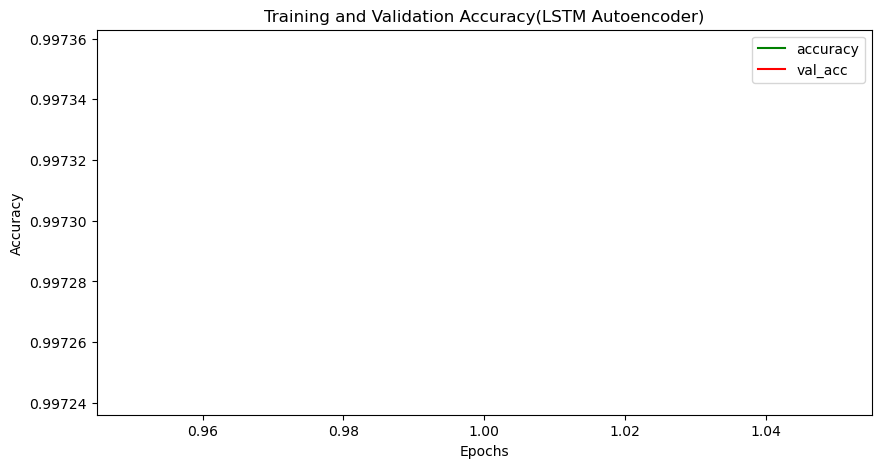

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title('Training and Validation Accuracy(LSTM Autoencoder)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.plot(epochs, acc, label='accuracy', color='g')
plt.plot(epochs, val_acc, label='val_acc', color='r')
plt.legend()
plt.show()

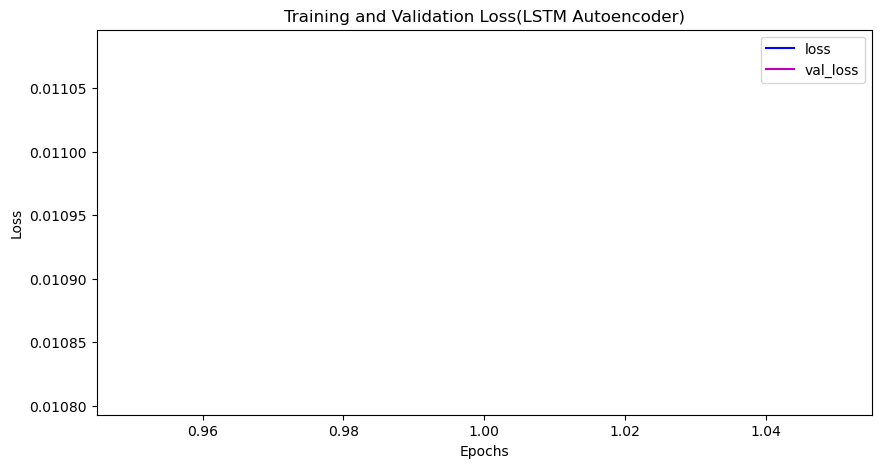

In [36]:
# visualize training and val loss
plt.figure(figsize=(10, 5))
plt.title('Training and Validation Loss(LSTM Autoencoder)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(epochs, loss, label='loss', color='b')
plt.plot(epochs, val_loss, label='val_loss', color='m')
plt.legend()
plt.show()

In [37]:
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)

Shape of X_train: (231316, 507)
Shape of y_train: (231316, 1)


In [38]:
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_test: (99136, 507)
Shape of y_test: (99136, 1)


In [ ]:
X_test

array([[-1.55414198, -0.97037796,  0.23826478, -0.27442811, -0.67381204],
       [-0.51815942,  1.75084929,  0.23826478, -0.27442811,  1.28294575],
       [ 0.82861792, -0.8375636 ,  0.3516828 , -0.27442811, -1.32606464],
       ...,
       [-0.89801969, -0.67574119,  0.23826478, -0.27442811, -1.32606464],
       [-0.3109629 ,  1.39720912,  0.23826478, -0.27442811, -0.67381204],
       [ 1.17394544, -0.54449271,  0.3516828 , -0.27442811, -0.02155944]])

3098/3098 [==============================] - 109s 35ms/step


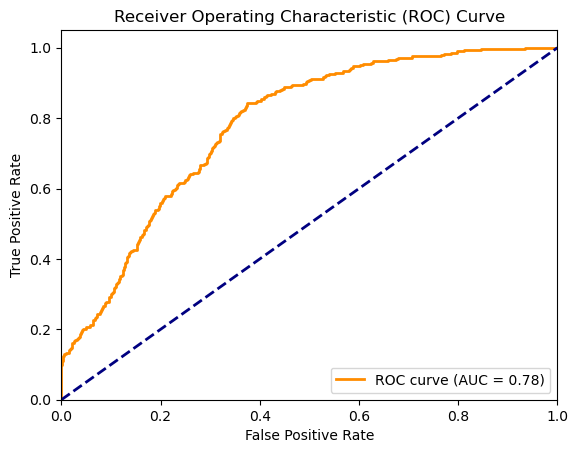

In [40]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# 1. Calculate Reconstruction Error
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
reconstructed_data = autoencoder.predict(X_test_reshaped)

reconstructed_data = reconstructed_data.reshape(reconstructed_data.shape[0], reconstructed_data.shape[1])
mse = np.mean(np.square(X_test - reconstructed_data), axis=1)

# 2. Ensure binary labels for ROC (0=normal, 1=anomalous)
y_true = (y_test.ravel() > 0).astype(int)

# 3. Compute ROC Curve and AUC-ROC
fpr, tpr, thresholds = roc_curve(y_true, mse)
auc_roc = auc(fpr, tpr)

# Plot ROC Curve
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % auc_roc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [41]:
from sklearn.metrics import classification_report

# Define threshold for classification (e.g., based on percentile or domain knowledge)
threshold = 0.5  # Adjust as needed

# Classify instances as normal (0) or anomalous (1) based on reconstruction error
y_pred = (mse > threshold).astype(int)

# Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.79      0.88     98852
           1       0.00      0.92      0.00        25
           2       0.00      0.00      0.00       252
           3       0.00      0.00      0.00         7

    accuracy                           0.79     99136
   macro avg       0.25      0.43      0.22     99136
weighted avg       1.00      0.79      0.88     99136



e:\anaconda\envs\tf-gpu310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\anaconda\envs\tf-gpu310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\anaconda\envs\tf-gpu310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


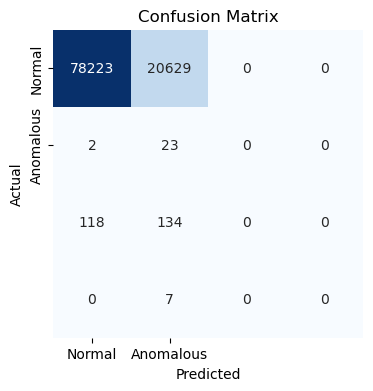

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a diagram with 4 squares
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Anomalous'], yticklabels=['Normal', 'Anomalous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [43]:
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Extract true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN)
TP = conf_matrix[1, 1]
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]

# Calculate recall, precision, false positive rate, and false negative rate
recall = TP / (TP + FN)
precision = TP / (TP + FP)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

# Print the metrics
print("Recall (True Positive Rate):", recall)
print("Precision:", precision)
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

Recall (True Positive Rate): 0.92
Precision: 0.0011136935889986441
False Positive Rate: 0.20868571197345526
False Negative Rate: 0.08


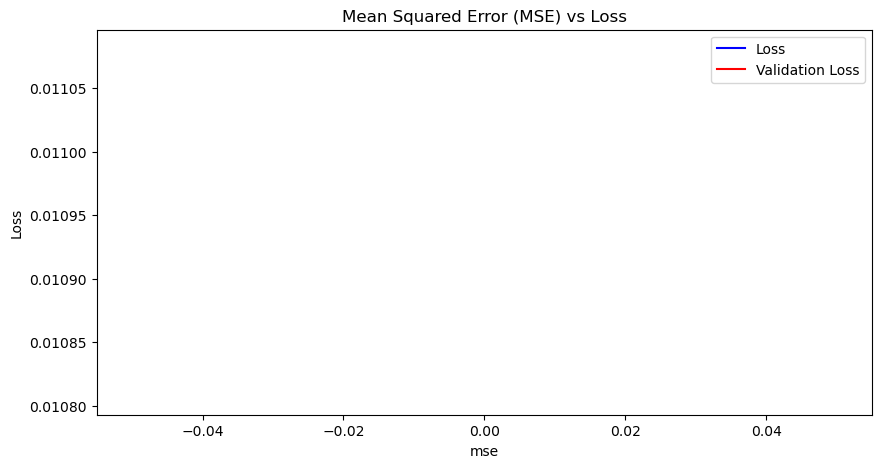

In [44]:
import matplotlib.pyplot as plt

# Plot Mean Squared Error (MSE) vs Loss
plt.figure(figsize=(10, 5))
plt.plot(autoencoder_history.history['loss'], label='Loss', color='blue')
plt.plot(autoencoder_history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Mean Squared Error (MSE) vs Loss')
plt.xlabel('mse')
plt.ylabel('Loss')
plt.legend()
plt.show()

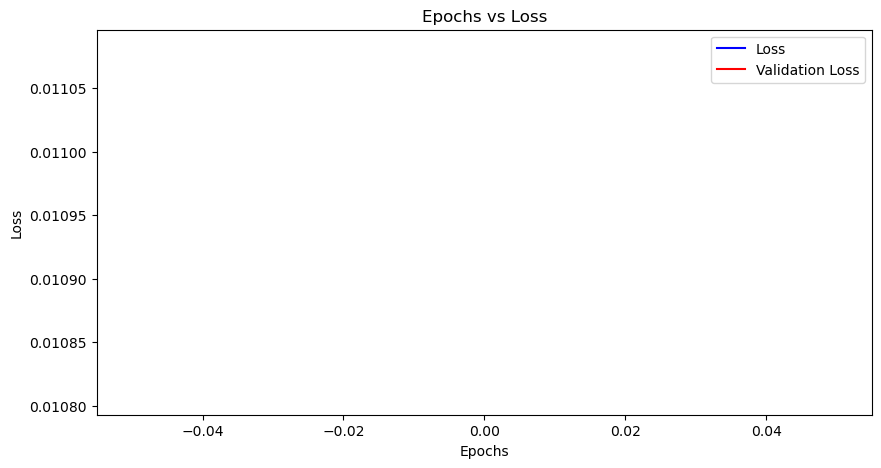

In [45]:


# Plot Mean Squared Error (MSE) vs Loss
plt.figure(figsize=(10, 5))
plt.plot(autoencoder_history.history['loss'], label='Loss', color='blue')
plt.plot(autoencoder_history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Epochs vs Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

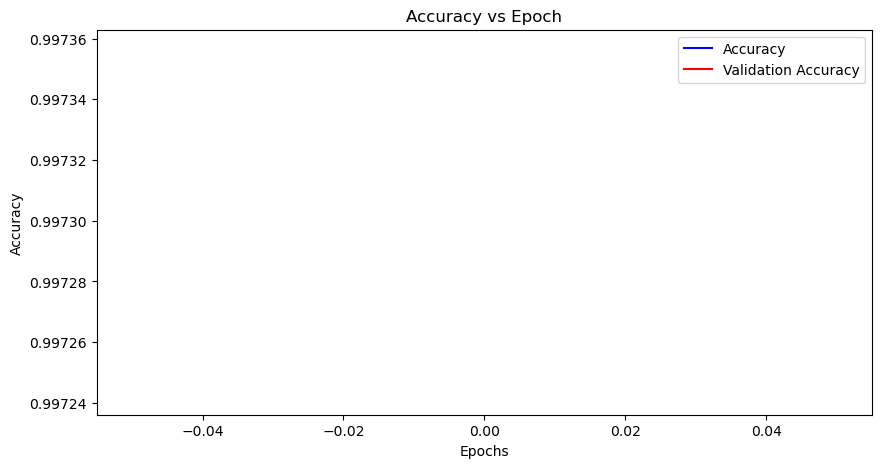

In [46]:
import matplotlib.pyplot as plt

# Plot Accuracy vs Epoch
plt.figure(figsize=(10, 5))
plt.plot(autoencoder_history.history['accuracy'], label='Accuracy', color='blue')
plt.plot(autoencoder_history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()